# Append hand edit topography modifications to the interpolated topography

In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('src/'))
from datetime import date

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import date
from topo_edit_util import inspect_topo, create_soc_topo_table

## Get input topography data set

In [3]:
path_root = './'

file_root = 'topo.'
grid = 'tx2_3v3'
topo_src = 'SRTM15_V2.4'
nsub = 'sub150'
edit_no_in = 1
case = 'SmL1.0_C1.0'
depth_var_in = 'D_interp'

edit_no_out = 2
depth_var_new = 'D_edit'+ '{:d}'.format(edit_no_out)

In [4]:
path_in = path_root 

print(path_in)

file_in = file_root + nsub +  '.' + grid + '.' + topo_src + '.edit' + '{:d}'.format(edit_no_in) + '.' + case + '.nc'
print(file_in)
dss = xr.open_dataset(path_in+file_in)

path_out = path_in
file_out = file_root + nsub +  '.' + grid + '.' + topo_src + '.edit' + '{:d}'.format(edit_no_out) + '.' + case + '.nc'
print(file_out)

dss[depth_var_new] = dss[depth_var_in].copy(deep=True)

./
topo.sub150.tx2_3v3.SRTM15_V2.4.edit1.SmL1.0_C1.0.nc
topo.sub150.tx2_3v3.SRTM15_V2.4.edit2.SmL1.0_C1.0.nc


In [5]:
dss

<xarray.Dataset> Size: 21MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/16)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
    D_edit2     (lath, lonh) float32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260226
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/27/2026

### Set up the SOC depth table

In [6]:
soc_table = create_soc_topo_table()

## Hand edit topography changes

In [7]:
iEdit=[]
jEdit=[]
zEdit = []

### Sanhihe Islands (between Philippines and Indonesia)

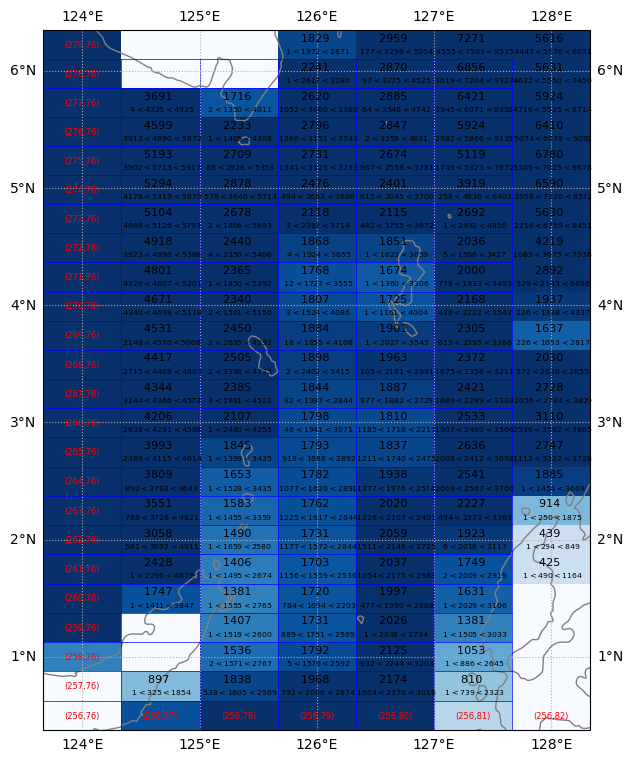

In [8]:
place = ' '
#print(soc_table[place])
lon_beg = -236.
lon_end = -231.5
lat_beg = 0.5
lat_end = 6.5
zmax = 2000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

18


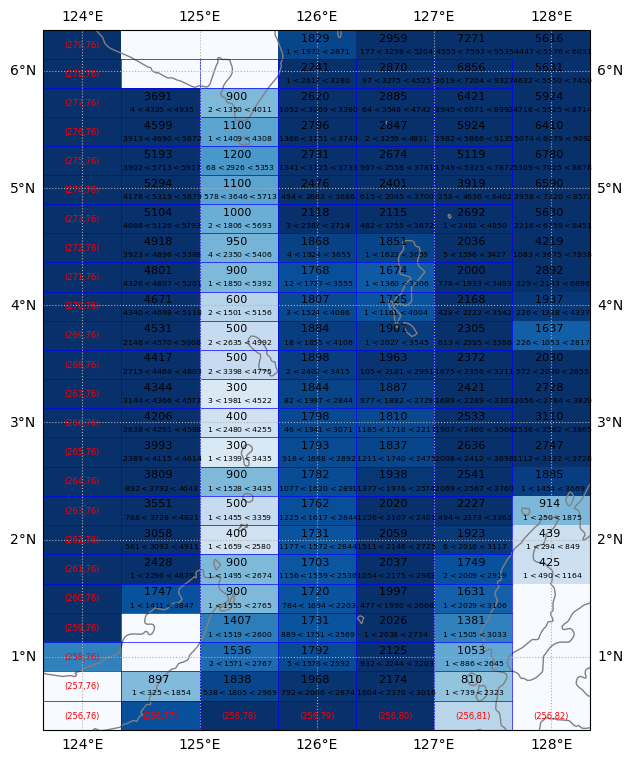

In [9]:
i = np.ones(18, dtype=np.int32) * 78
j = np.arange(260,278,1, dtype=np.int32) 
z = np.array([900,900,400, 500, 900,300,400,300,500,500,600,900,
              950,1000,1100,1200,1100,900],float)
n = np.shape(z)[0]
print(n)
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = z[n]

ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

iEdit = np.concatenate((iEdit,i))
jEdit = np.concatenate((jEdit,j))
zEdit = np.concatenate((zEdit,z))

### Sulu Sea

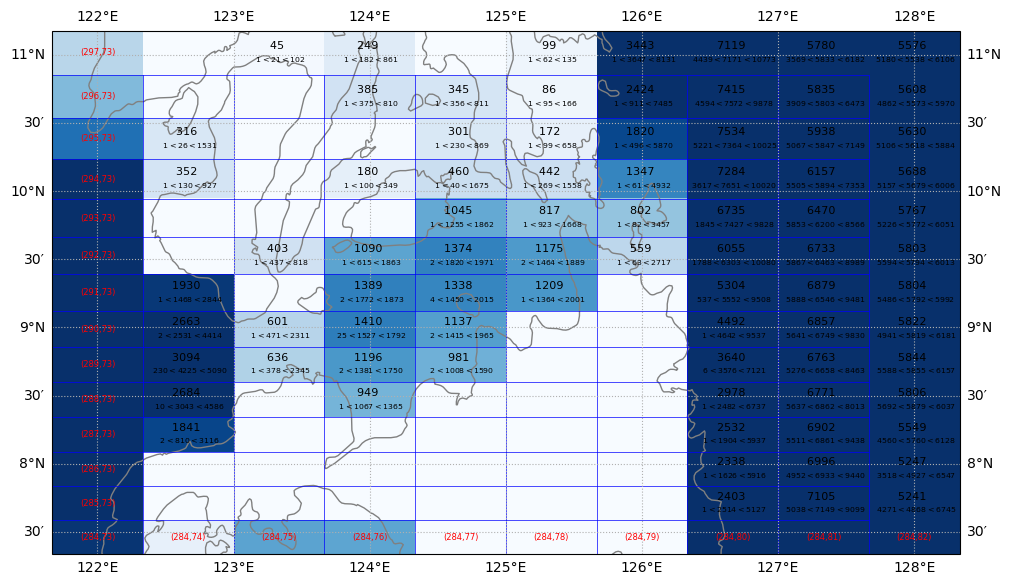

In [10]:
place = ' '
#print(soc_table[place])
lon_beg = -238
lon_end = -231.5
lat_beg = 7.5
lat_end = 11.5
zmax = 2000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

4


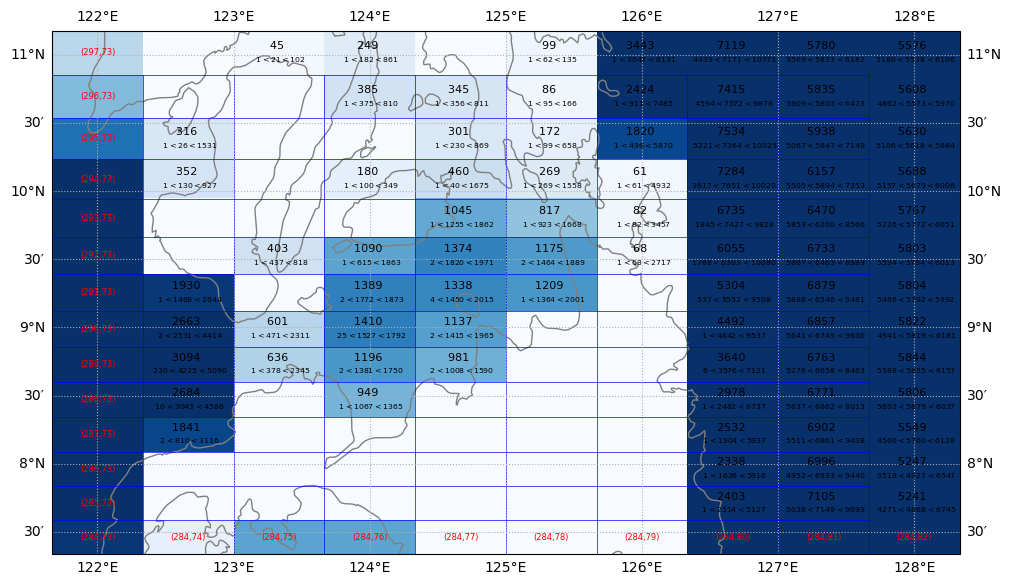

In [11]:
i = np.array([78,79,79, 79],np.int32)
j = np.array([294,292,293, 294],np.int32)
z = np.array([269,68,82, 61],float)
n = np.shape(z)[0]
print(n)
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = z[n]

ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

iEdit = np.concatenate((iEdit,i))
jEdit = np.concatenate((jEdit,j))
zEdit = np.concatenate((zEdit,z))

### Bosphorus

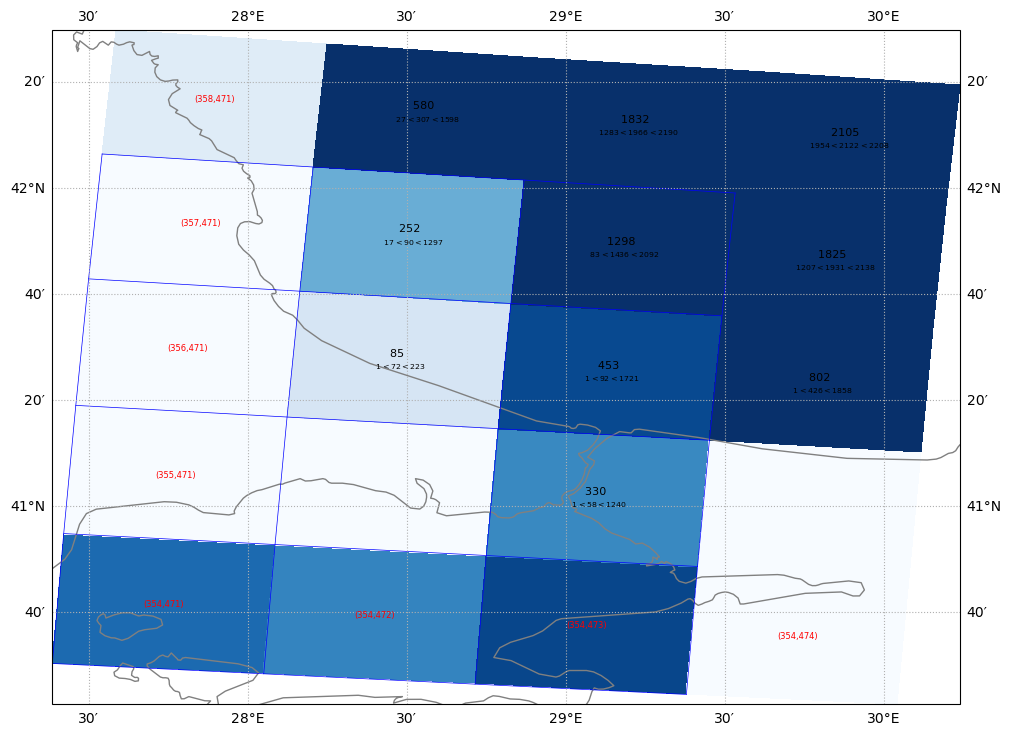

In [12]:
## Black Sea / Bosphorus
lon_beg = 28
lon_end = 30.5
lat_beg = 40.5
lat_end = 42.5
zmax = 500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

1


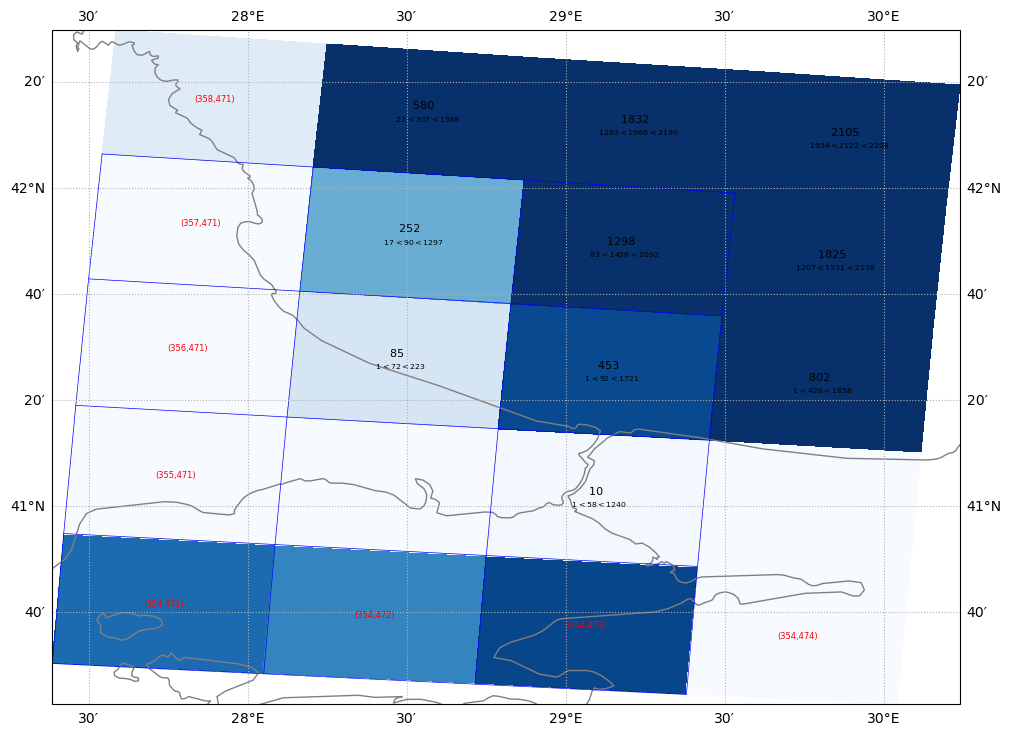

In [13]:
i = np.array([473,],np.int32)
j = np.array([355,],np.int32)
z = np.array([10.],np.int32)
n = np.shape(j)[0]
print(n)

for n in range(n) :
    #z = dss['D_median'][j[n],i[n]]
    dss[depth_var_new][j[n],i[n]] = z[n]
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(z[n],)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)


### Dardanelles

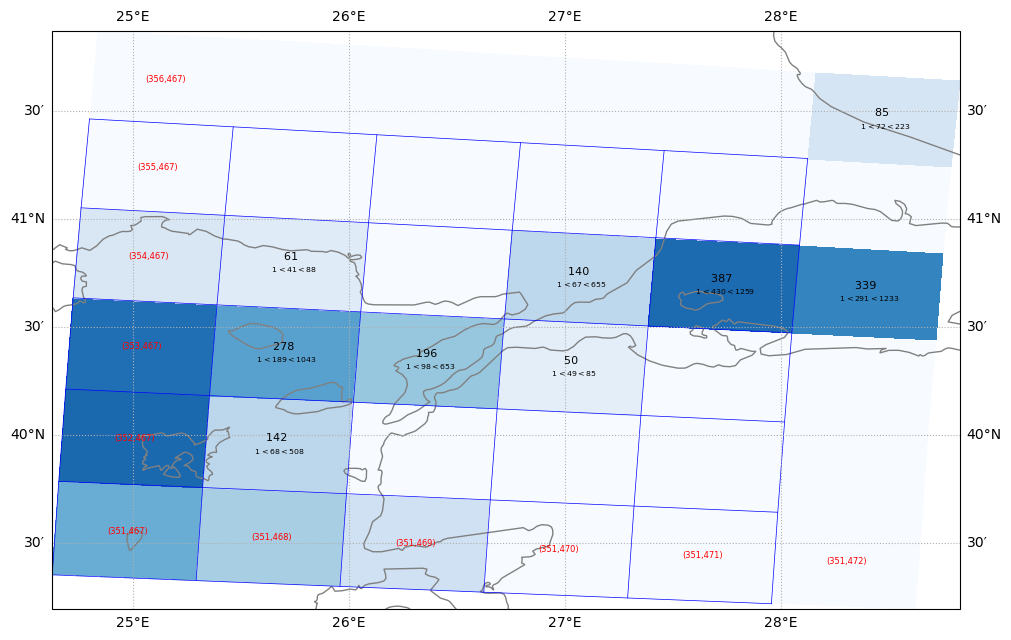

In [14]:
## Black Sea / Dardannelles
lon_beg = 25
lon_end = 29
lat_beg = 39.5
lat_end = 42
zmax = 500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)


2


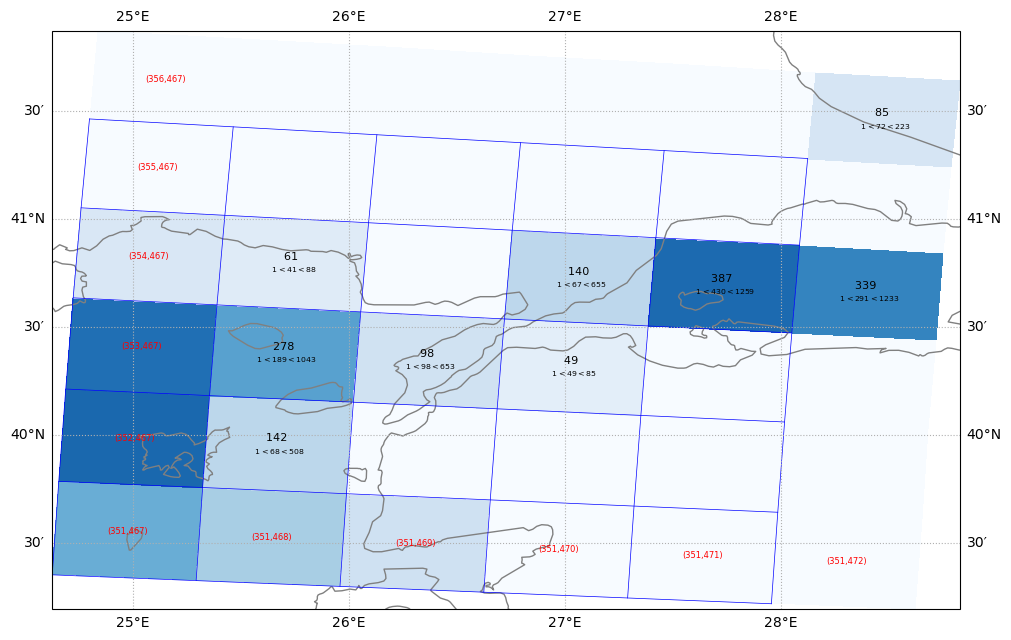

In [15]:
i = np.array([469,470,],np.int32)
j = np.array([353,353,],np.int32)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    z = dss['D_median'][j[n],i[n]]
    dss[depth_var_new][j[n],i[n]] = z
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(z,)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)


### Denmark St.

{'lat': 66.0, 'lon': -28.0, 'depth': 600.0, 'width': -1.0}


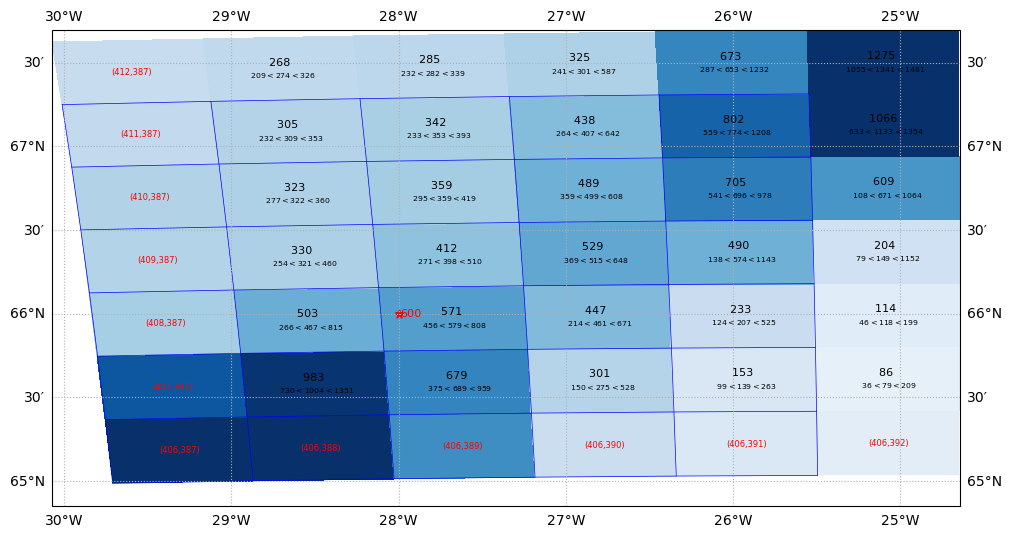

In [16]:
place = 'Denmark St.'
print(soc_table[place])
      
lon_beg = -29.5
lon_end = -24
lat_beg = 65
lat_end = 68
zmax = 1000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

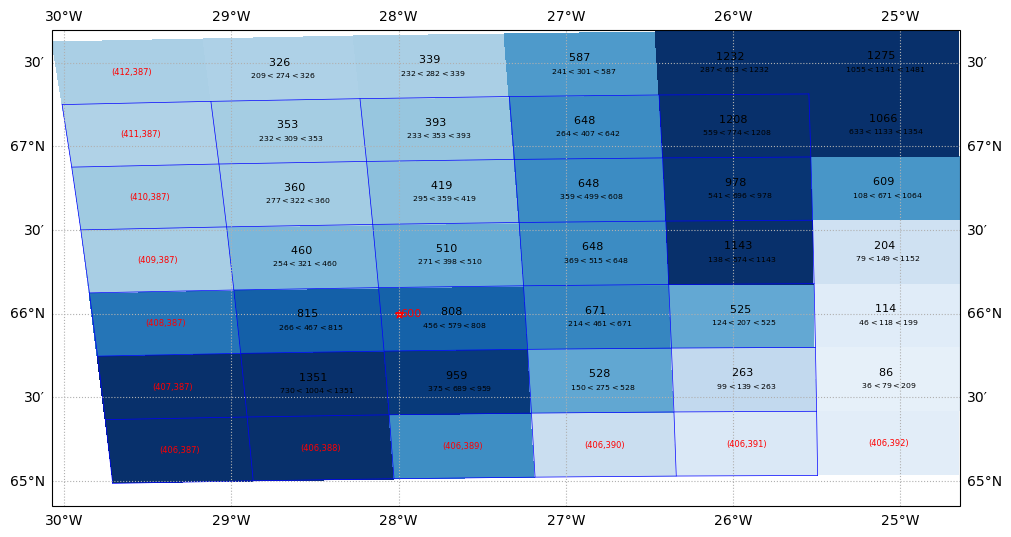

In [17]:
# use the cell maximum around the sill
for i in range(386,392):
    for j in range(407,413):
        if dss['mask'][j,i] != 0 :
            z = dss['D_max'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))        

i = 390
z = 648
for j in range(409,412):
    dss[depth_var_new][j,i] = z
    iEdit = np.concatenate((iEdit,(i,)))
    jEdit = np.concatenate((jEdit,(j,)))
    zEdit = np.concatenate((zEdit,(z,)))


ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


### Faroe Bank Channel

{'lat': 61.5, 'lon': -8.5, 'depth': 800.0, 'width': 15.0}


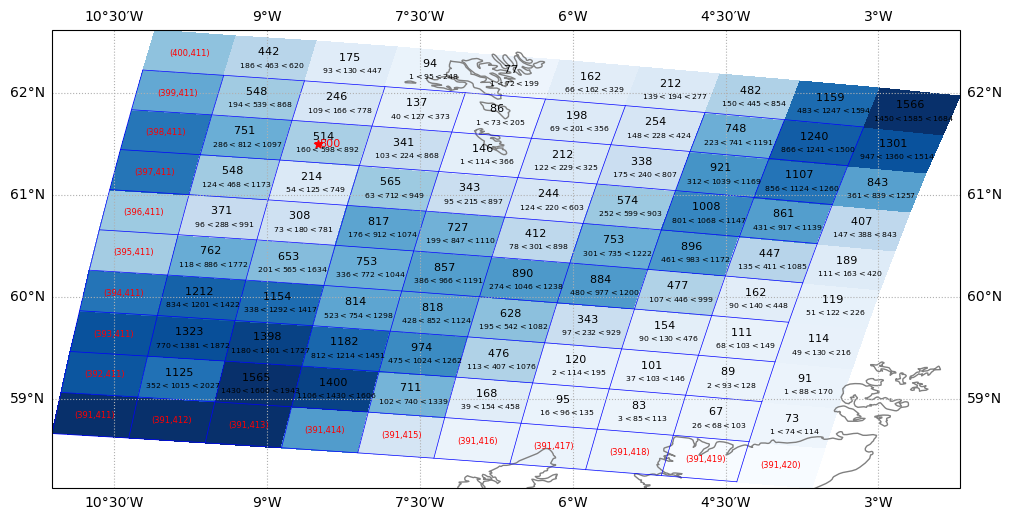

In [18]:
place='Faroe Bank Channel'
print(soc_table[place])
lon_beg = -11
lon_end = -2
lat_beg = 59.
lat_end = 62
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


17


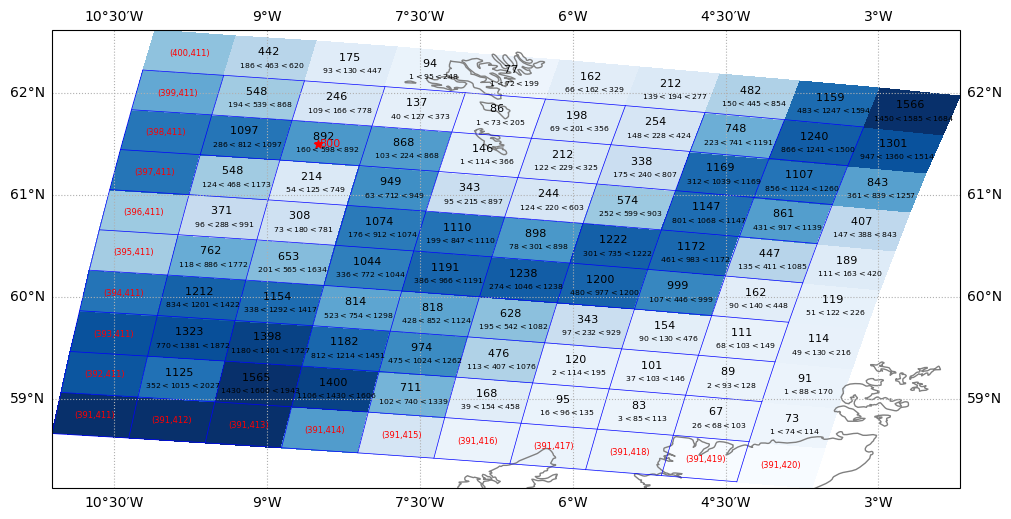

In [19]:
i = np.array([418,418,418,418,418,417,417,416,416,415,415,414,414,414,414,413,412,],np.int32)
j = np.array([395,396,397,398,397,396,395,395,396,395,396,395,396,397,398,398,398,],np.int32)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = dss['D_max'][j[n],i[n]]
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(dss['D_max'][j[n],i[n]],)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


### Strait of Gibralter

{'lat': 35.92, 'lon': -5.75, 'depth': 284.0, 'width': 10.0}


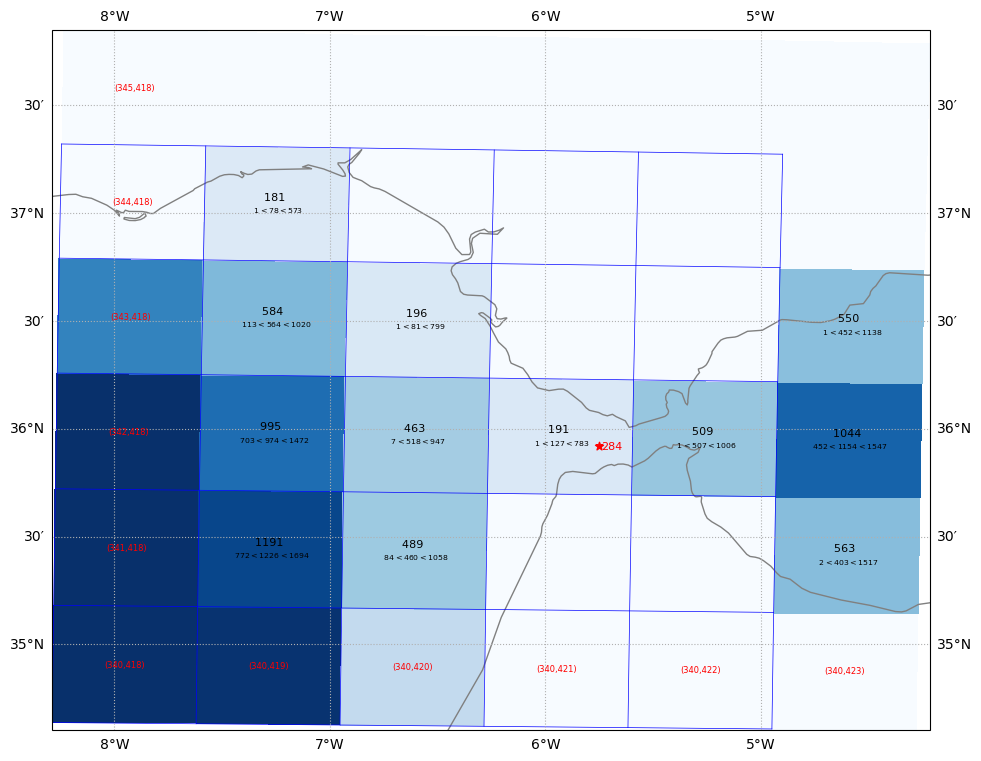

In [20]:
place = 'St. of Gibralter'
print(soc_table[place])
lon_beg = -8
lon_end = -4
lat_beg = 35
lat_end = 38
zmax = 1300.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

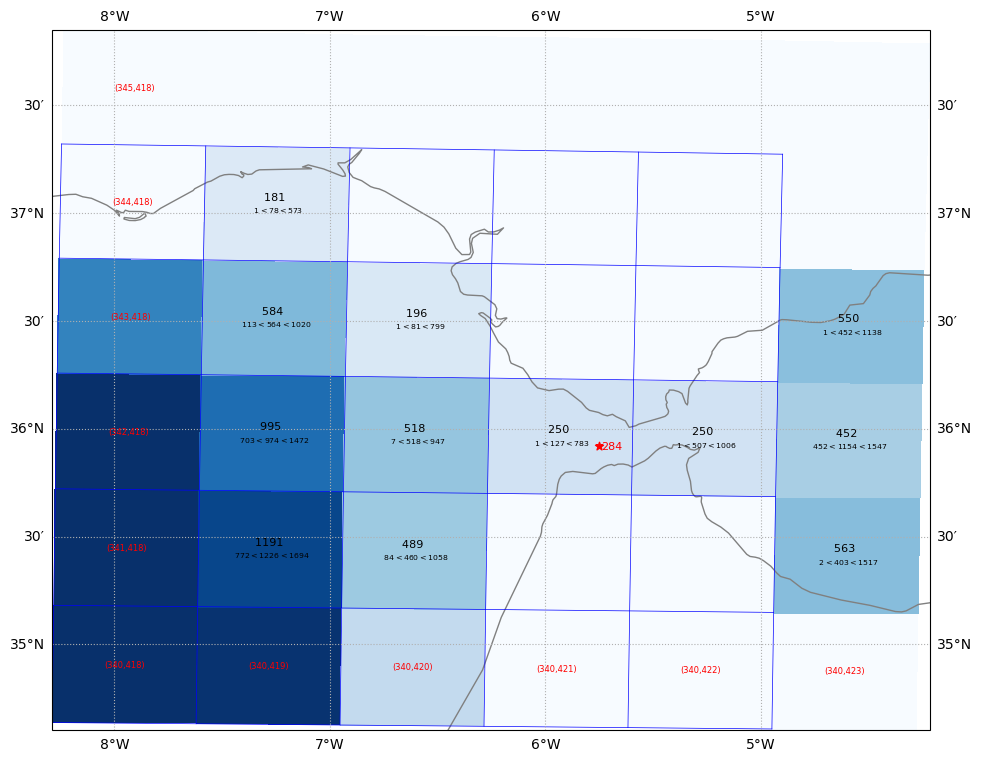

In [21]:
# use the cell median west of the sill
i = 420
j = 342
if dss['mask'][j,i] != 0 :
    z = dss['D_median'][j,i]
    dss[depth_var_new][j,i] = z
    iEdit = np.concatenate((iEdit,(i,)))
    jEdit = np.concatenate((jEdit,(j,)))
    zEdit = np.concatenate((zEdit,(z,)))        

# Set the sill depth to (a little less than) the SOC table value
j = 342
z = 250.0
for i in range(421,423):
    dss[depth_var_new][j,i] = z
    iEdit = np.concatenate((iEdit,(i,)))
    jEdit = np.concatenate((jEdit,(j,)))
    zEdit = np.concatenate((zEdit,(z,)))        

# use the cell minimum east of the sill
i = 423
j = 342
if dss['mask'][j,i] != 0 :
    z = dss['D_min'][j,i]
    dss[depth_var_new][j,i] = z
    iEdit = np.concatenate((iEdit,(i,)))
    jEdit = np.concatenate((jEdit,(j,)))
    zEdit = np.concatenate((zEdit,(z,)))

ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

### Florida Strait

{'lat': 24.25, 'lon': -80.5, 'depth': 800.0, 'width': 60.0}


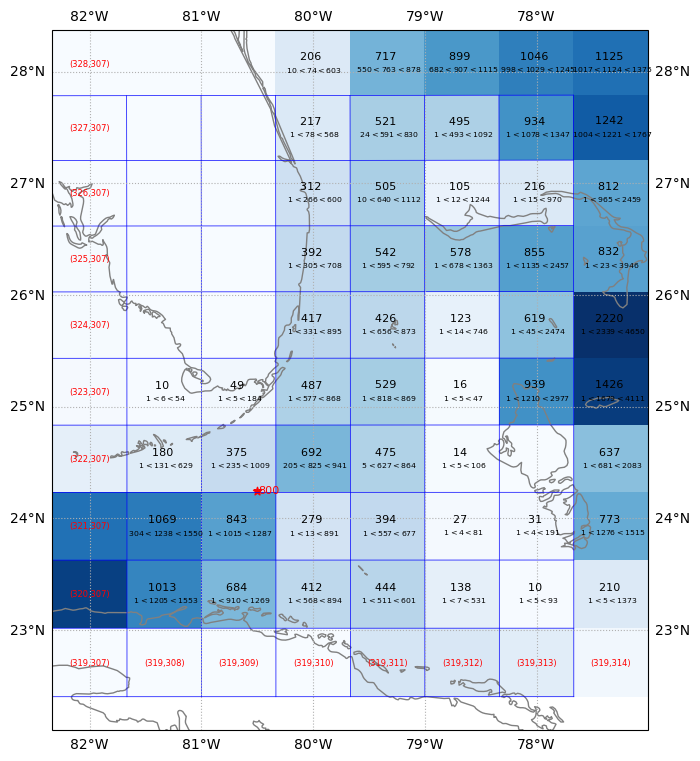

In [22]:
place = 'Florida St.'
print(soc_table[place])
lon_beg = -82
lon_end = -77
lat_beg = 23.
lat_end = 28.5
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

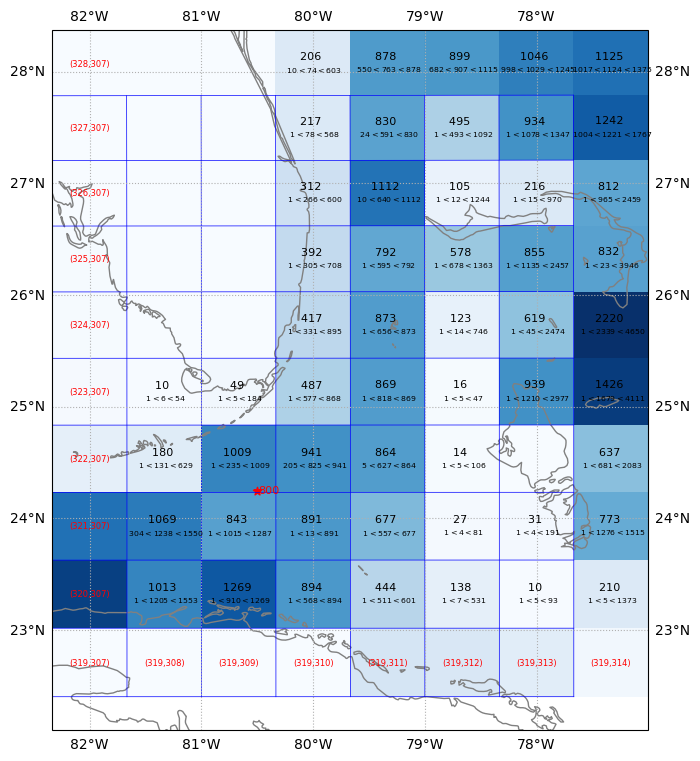

In [23]:
i = np.array([309,309,310,310,310,311,311,311,311,311,311,311,311],np.int32)
j = np.array([320,322,320,321,322,322,321,323,324,325,326,327,328],np.int32)
n = np.shape(j)[0]
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = dss['D_max'][j[n],i[n]]
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(dss['D_max'][j[n],i[n]],)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


### Windward Passage

{'lat': 19.0, 'lon': -74.0, 'depth': 1650.0, 'width': 22.0}


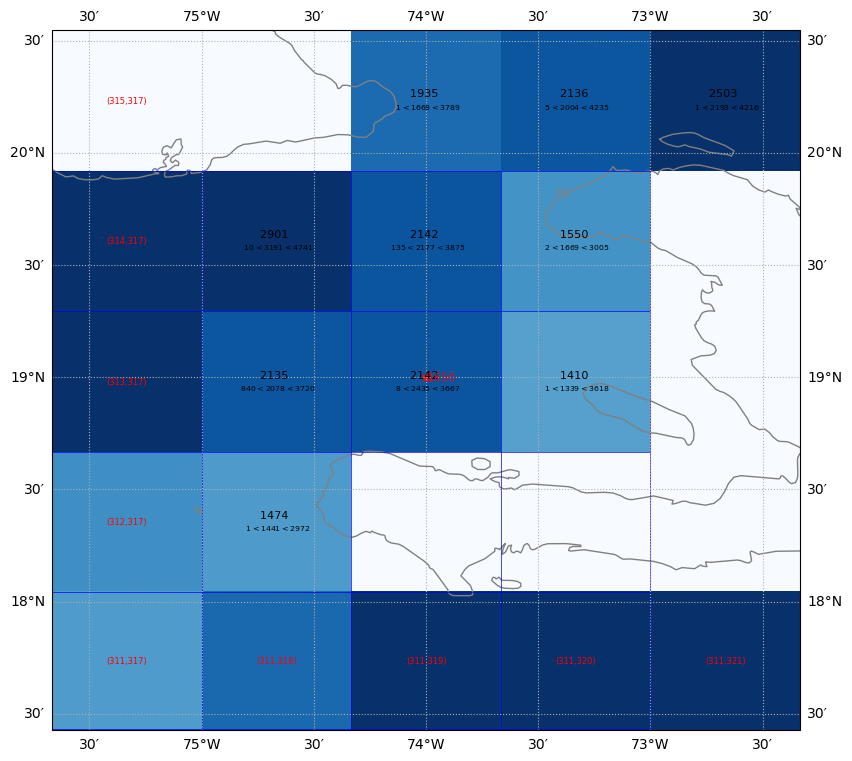

In [24]:
place = 'Windward Passage'
print(soc_table[place])
lon_beg = -75.5
lon_end = -72
lat_beg = 18
lat_end = 21
zmax = 2500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

2


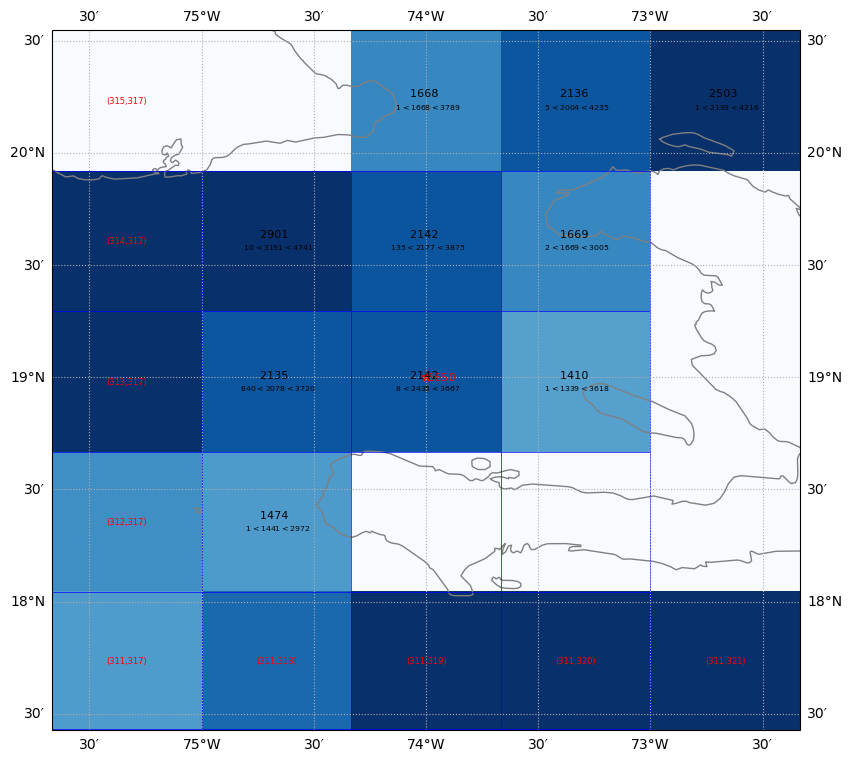

In [25]:
i = np.array([319,320,],np.int32)
j = np.array([315,314,],np.int32)
z = np.array([1650,],float)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    z = dss['D_median'][j[n],i[n]]
    dss[depth_var_new][j[n],i[n]] = z
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(z,)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


### Anegada Passage

{'lat': 18.4, 'lon': -64.2, 'depth': 1800.0, 'width': 15.0}


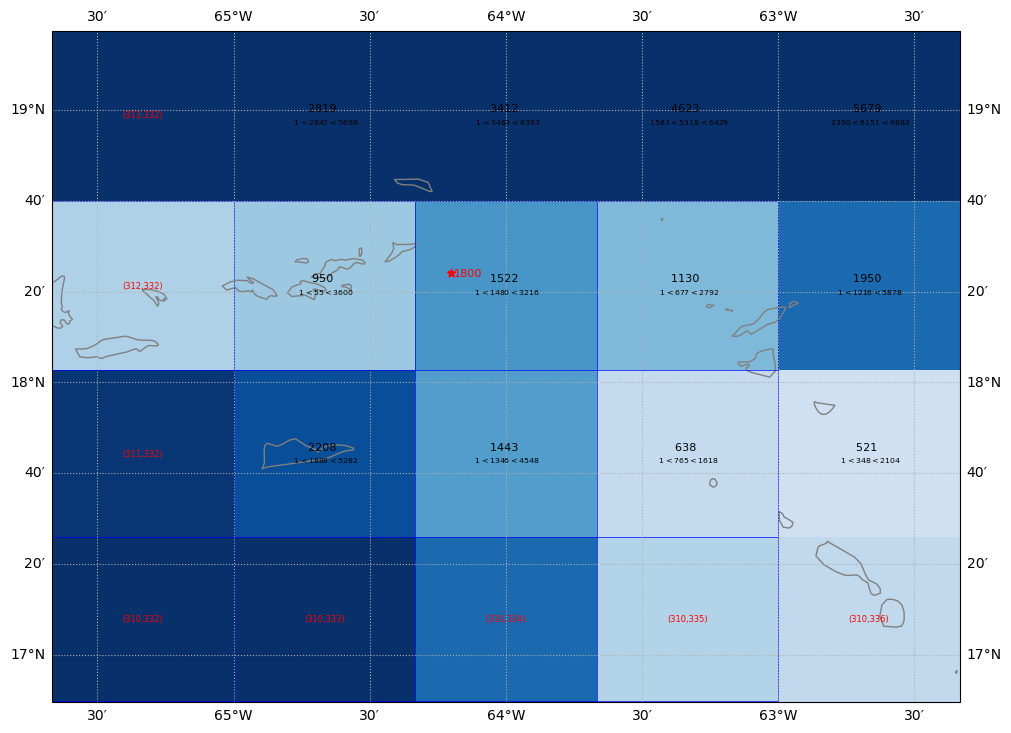

In [26]:
place = 'Anegada Passage'
print(soc_table[place])
lon_beg = -65.5
lon_end = -62.
lat_beg = 17
lat_end = 19.5
zmax = 2500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

2


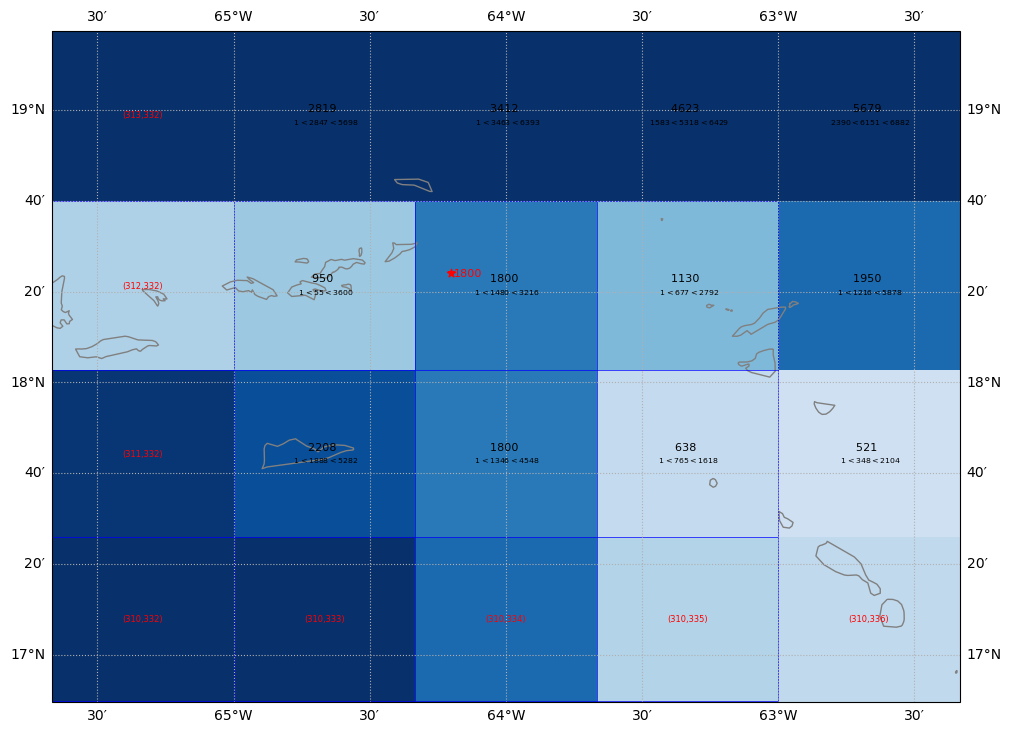

In [27]:
i = np.array([334,334,],np.int32)
j = np.array([311,312,],np.int32)
z = np.array([1800,1800,],float)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = z[n]
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

        
iEdit = np.concatenate((iEdit,i))
jEdit = np.concatenate((jEdit,j))
zEdit = np.concatenate((zEdit,z))

### Guiana Basin

{'lat': 18.4, 'lon': -64.2, 'depth': 1800.0, 'width': 15.0}


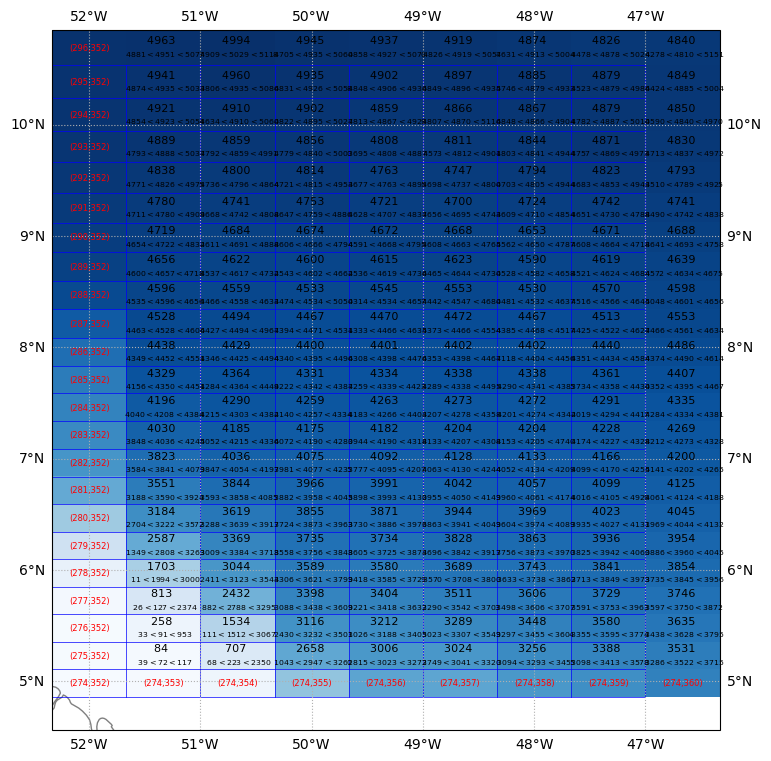

In [28]:
print(soc_table[place])
lon_beg = -52
lon_end = -46
lat_beg = 5
lat_end = 11
zmax = 5000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Ceara Rise

{'lat': 3.0, 'lon': -39.42, 'depth': 4300.0, 'width': 300.0}


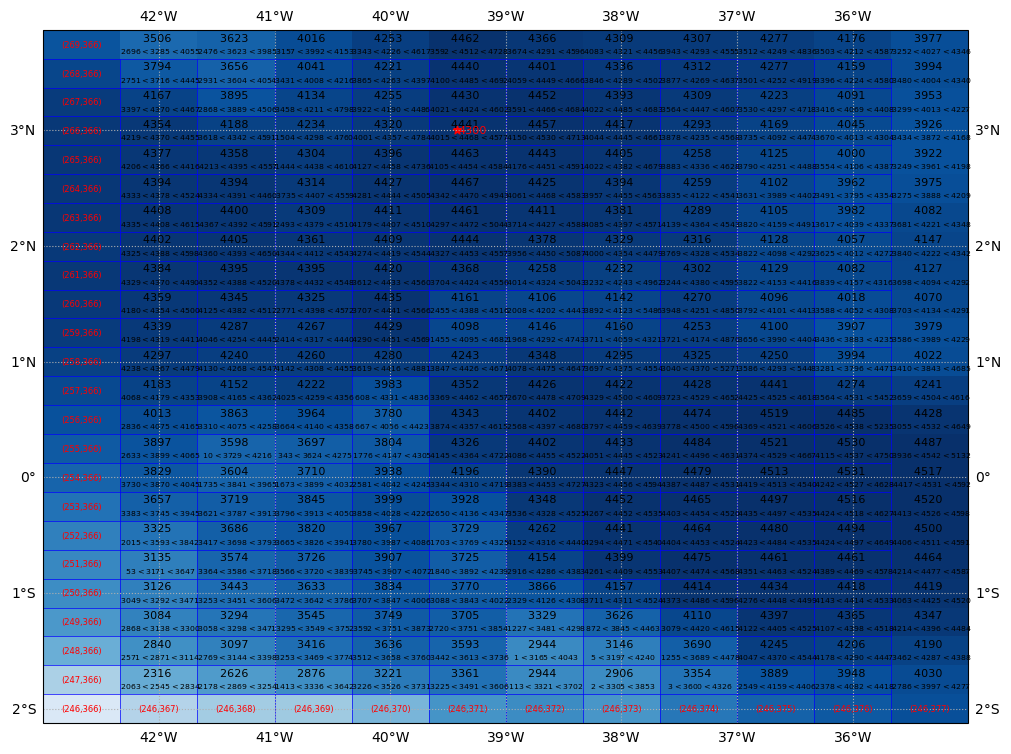

In [29]:
place = 'Ceara Rise'
print(soc_table[place])
lon_beg = -43
lon_end = -35
lat_beg = -2
lat_end = 4
zmax = 4500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

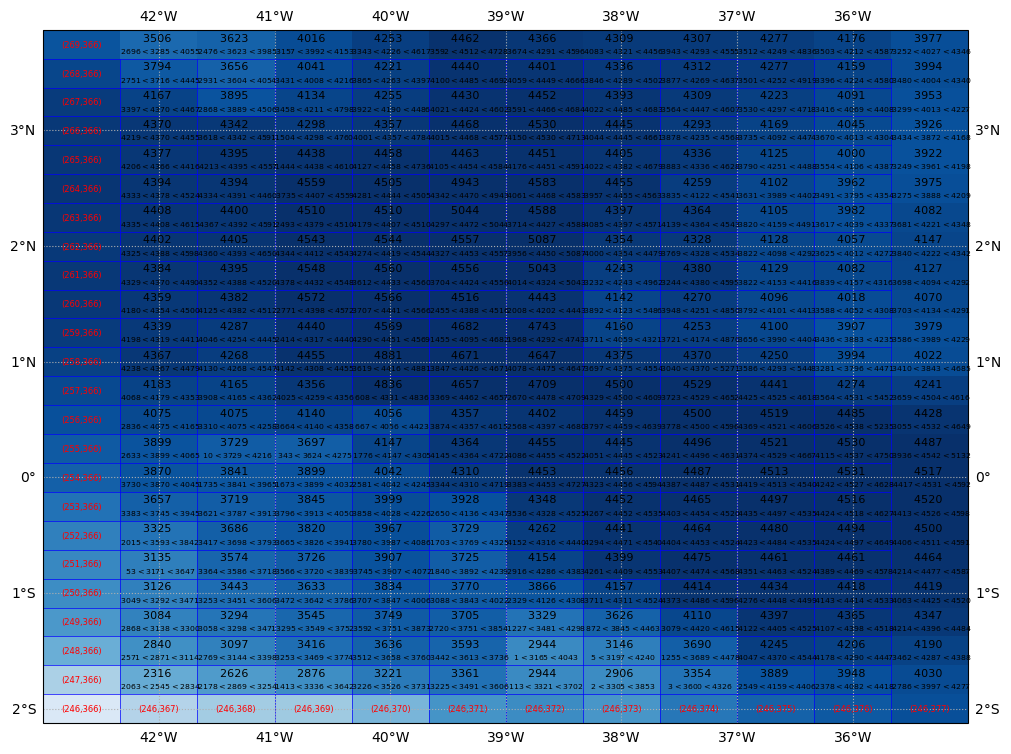

In [30]:
# Try to deepen broadly
for i in range(366,375):
    for j in range(254,267):
        if dss['mask'][j,i] !=0 and dss['D_median'][j,i] > dss['D_interp'][j,i] :
#            print(i,j,
#                  dss['D_interp'][j,i].values,
#                  dss['D_min'][j,i].values,
#                  dss['D_median'][j,i].values,
#                  dss['D_max'][j,i].values)
            z = dss['D_median'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))

# Deepen more near the constriction
for i in range(369,373):
    for j in range(257,265):
        if dss['mask'][j,i] !=0  :
            z = dss['D_max'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))


ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Pernambuco Seamounts

{'lat': 3.0, 'lon': -39.42, 'depth': 4300.0, 'width': 300.0}


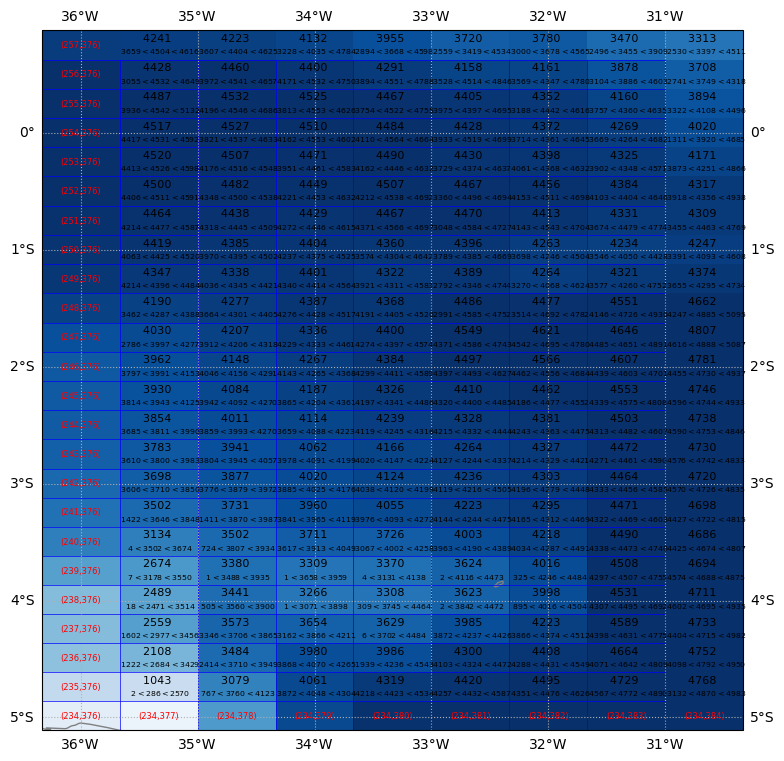

In [31]:
print(soc_table[place])
lon_beg = -36
lon_end = -30
lat_beg = -5
lat_end = 1
zmax = 4500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

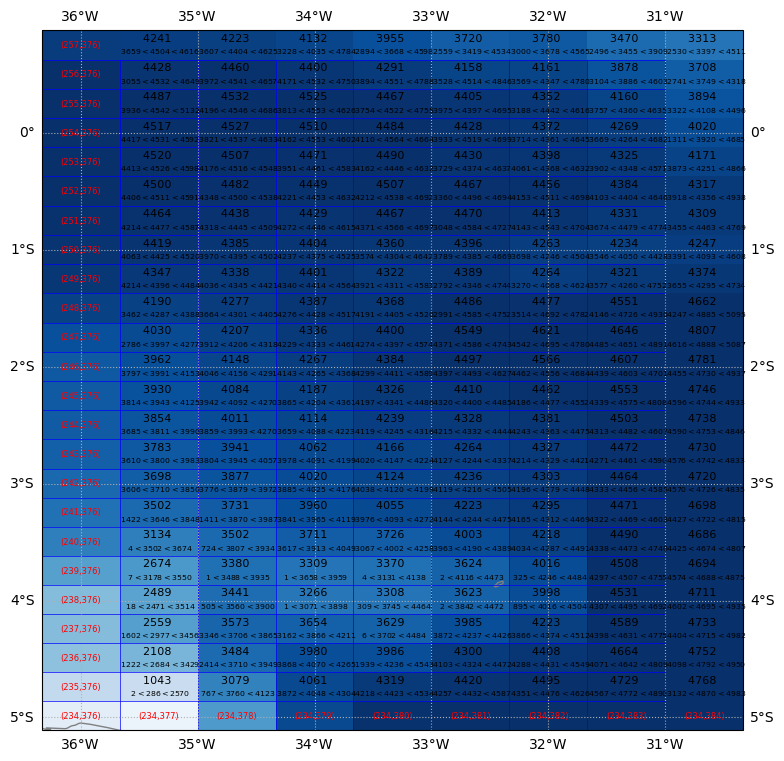

In [32]:

for i in range(369,373):
    for j in range(257,265):
        if dss['mask'][j,i] !=0  :
            z = dss['D_max'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))


ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Romanche/Chain F.Z.

{'lat': 3.0, 'lon': -39.42, 'depth': 4300.0, 'width': 300.0}


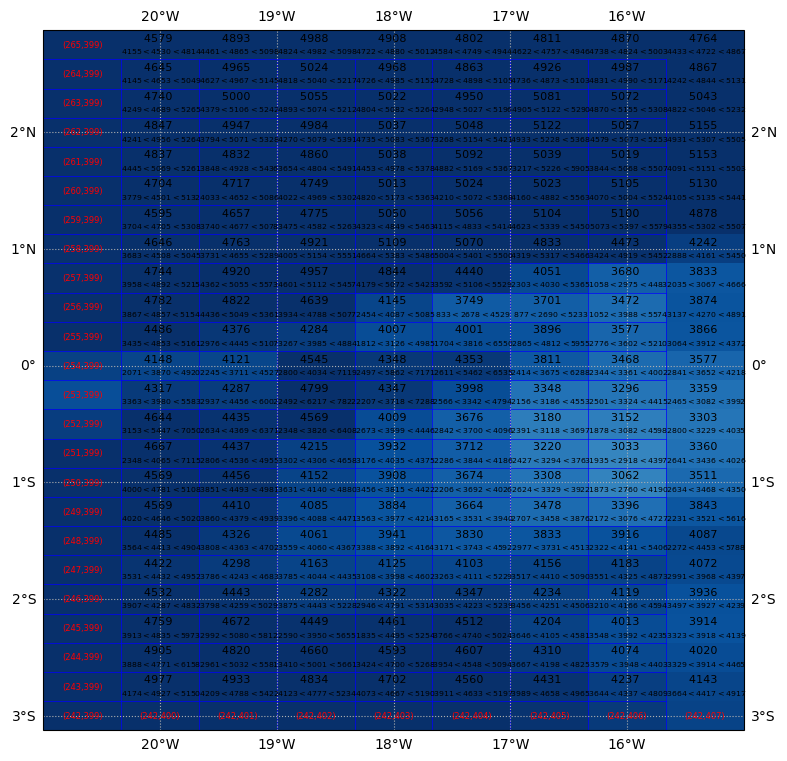

In [33]:
print(soc_table[place])
lon_beg = -21
lon_end = -15
lat_beg = -3
lat_end = 3
zmax = 4500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

5


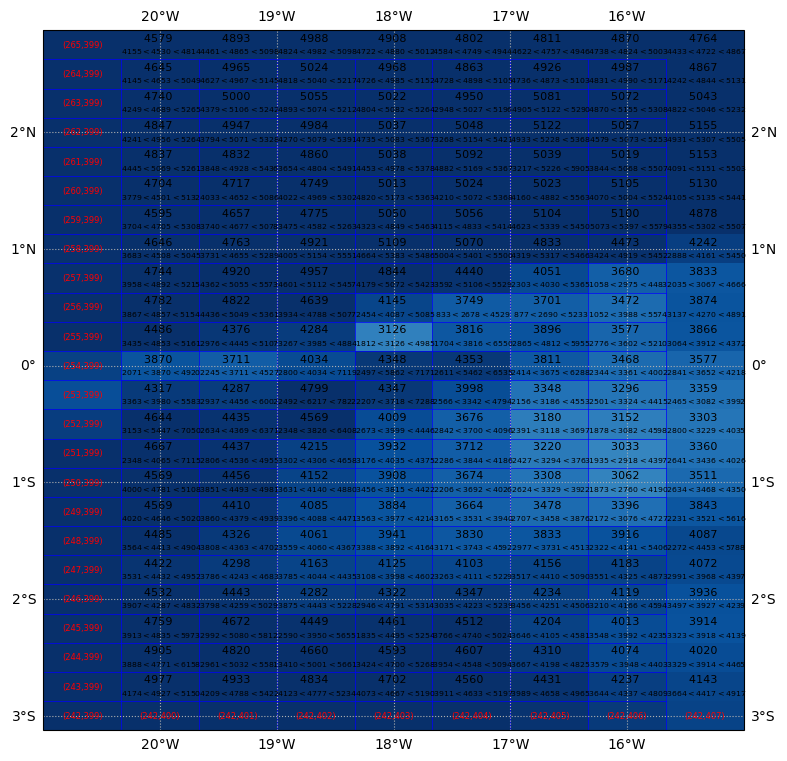

In [34]:
i = np.array([400,401,402,403,404],np.int32)
j = np.array([254,254,254,255,255,],np.int32)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    z = dss['D_median'][j[n],i[n]]
    dss[depth_var_new][j[n],i[n]] = z
    iEdit = np.concatenate((iEdit,(i[n],)))
    jEdit = np.concatenate((jEdit,(j[n],)))
    zEdit = np.concatenate((zEdit,(z,)))
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Vema Channel

{'lat': -28.66, 'lon': -38.0, 'depth': 4200.0, 'width': -1.0}


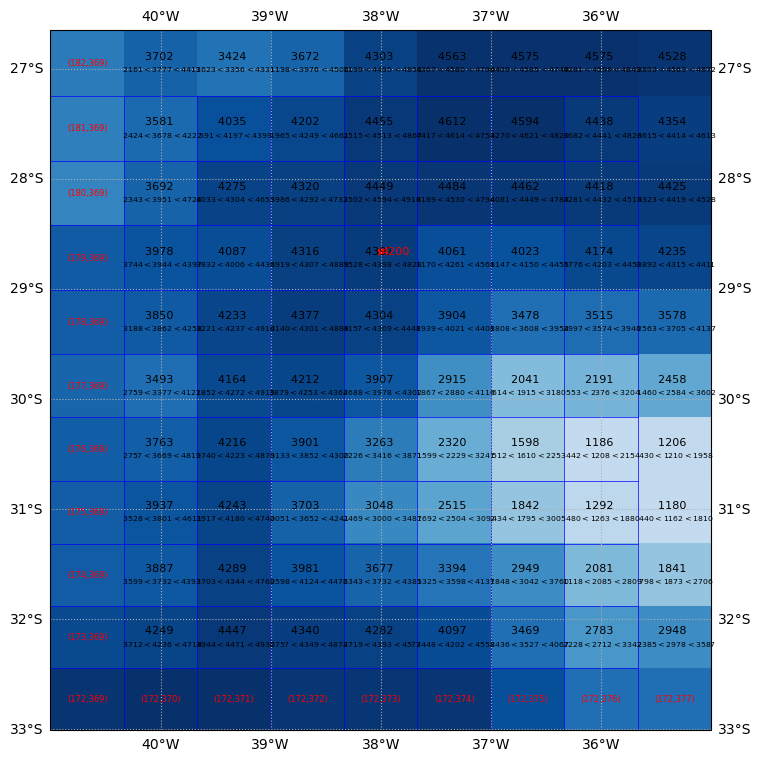

In [35]:
place = 'Vema Sill'
print(soc_table[place])
lon_beg = -41.
lon_end = -35
lat_beg = -33
lat_end = -26.5
zmax = 4600.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

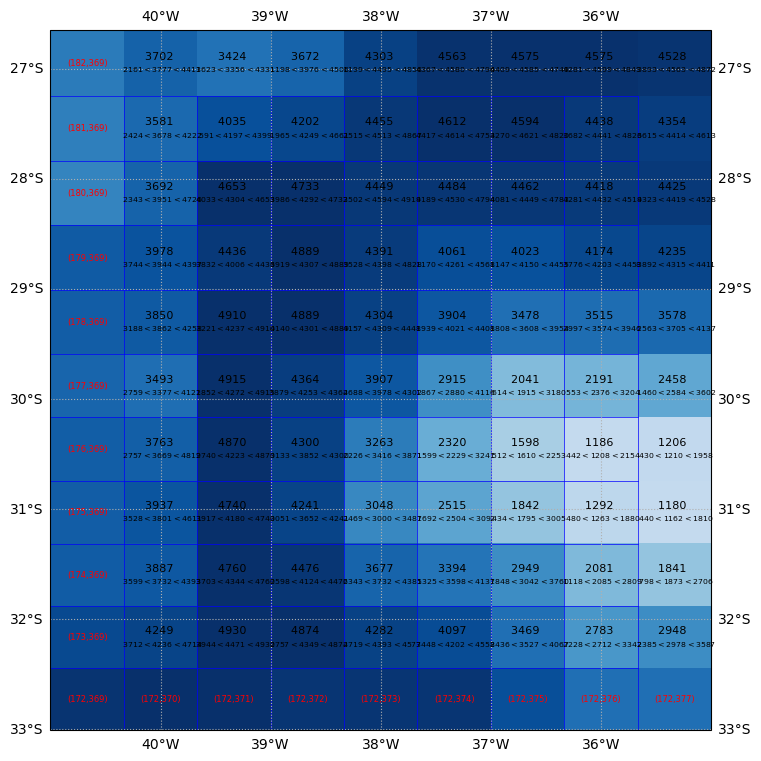

In [36]:

for i in range(371,373):
    for j in range(173,181):
        if dss['mask'][j,i] !=0  :
            z = dss['D_max'][j,i]
            dss[depth_var_new][j,i] = z
            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))        

ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

{'lat': -28.66, 'lon': -38.0, 'depth': 4200.0, 'width': -1.0}


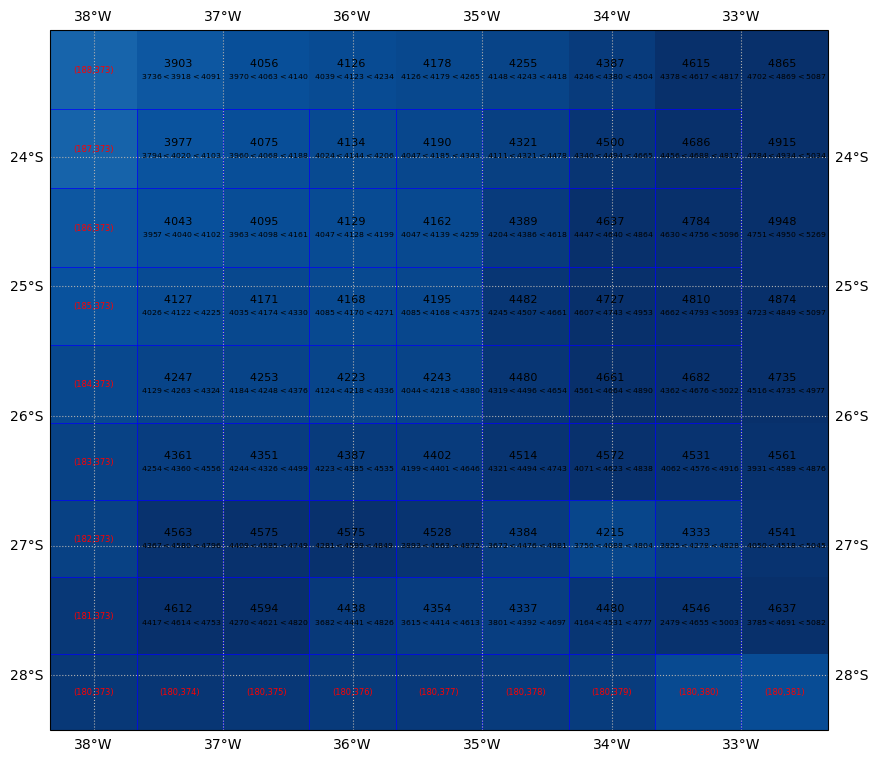

In [37]:
place = 'Vema Sill'
print(soc_table[place])
lon_beg = -38
lon_end = -32
lat_beg = -28
lat_end = -23
zmax = 4600.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

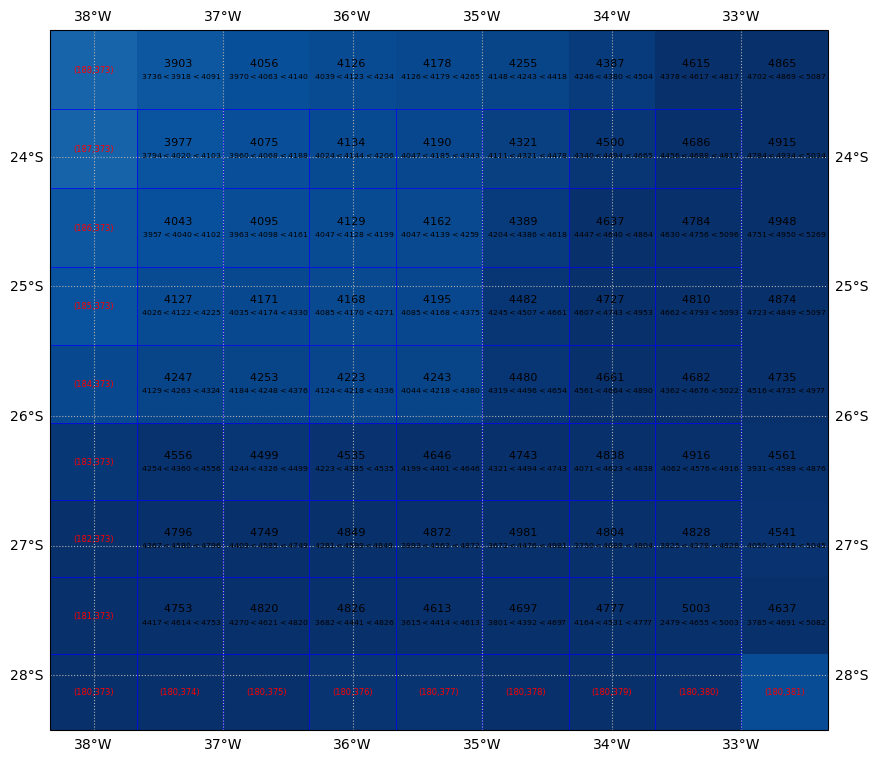

In [38]:

for i in range(373,381):
    for j in range(180,184):
        if dss['mask'][j,i] !=0  :
            z = dss['D_max'][j,i]
            dss[depth_var_new][j,i] = z
            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))        

ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Hunter Channel

{'lat': -35.0, 'lon': -27.0, 'depth': 4300.0, 'width': -1.0}


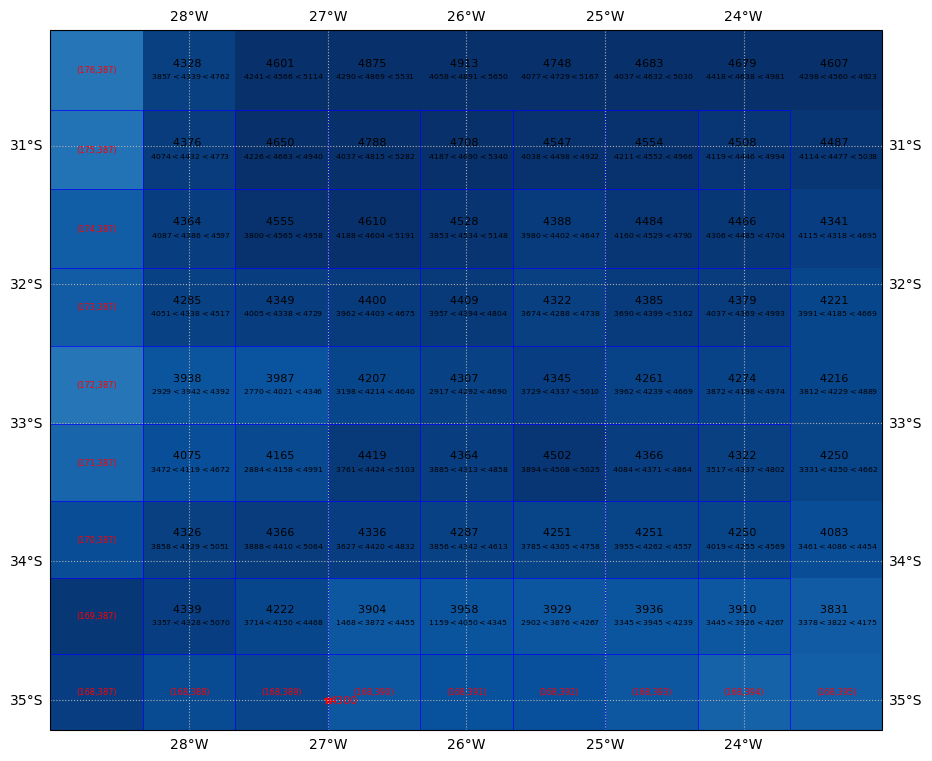

In [39]:
place = 'Hunter Channel'
print(soc_table[place])
lon_beg = -29
lon_end = -23
lat_beg = -35
lat_end = -30
zmax = 4600.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

### Lombok Strait

{'lat': -8.9, 'lon': 116.0, 'depth': 350.0, 'width': 22.0}


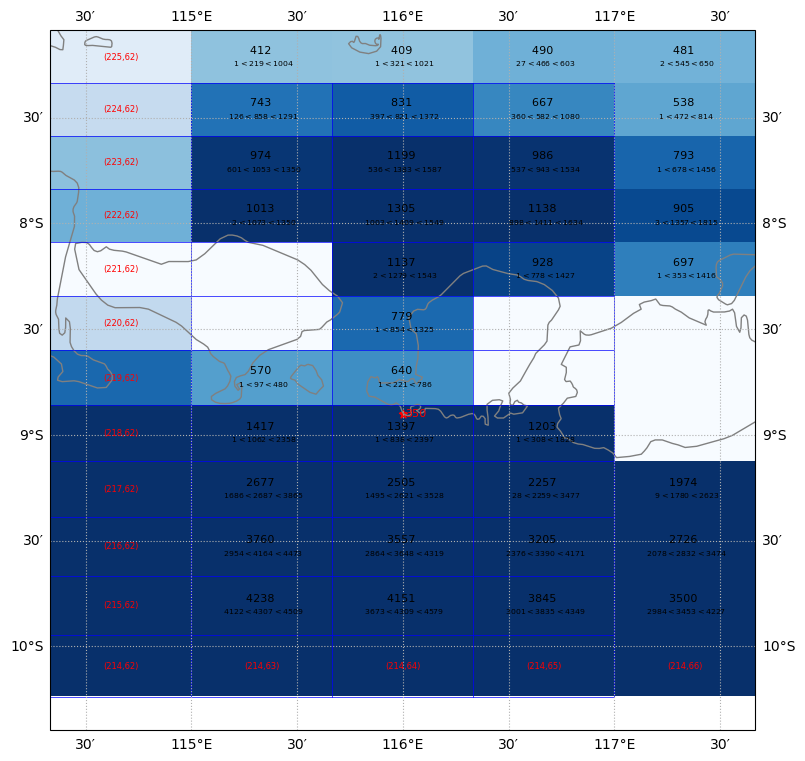

In [40]:
place = 'Lombok St.'
print(soc_table[place])
lon_beg = -245.5
lon_end = -242.
lat_beg = -10
lat_end = -7.
zmax = 1000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

1


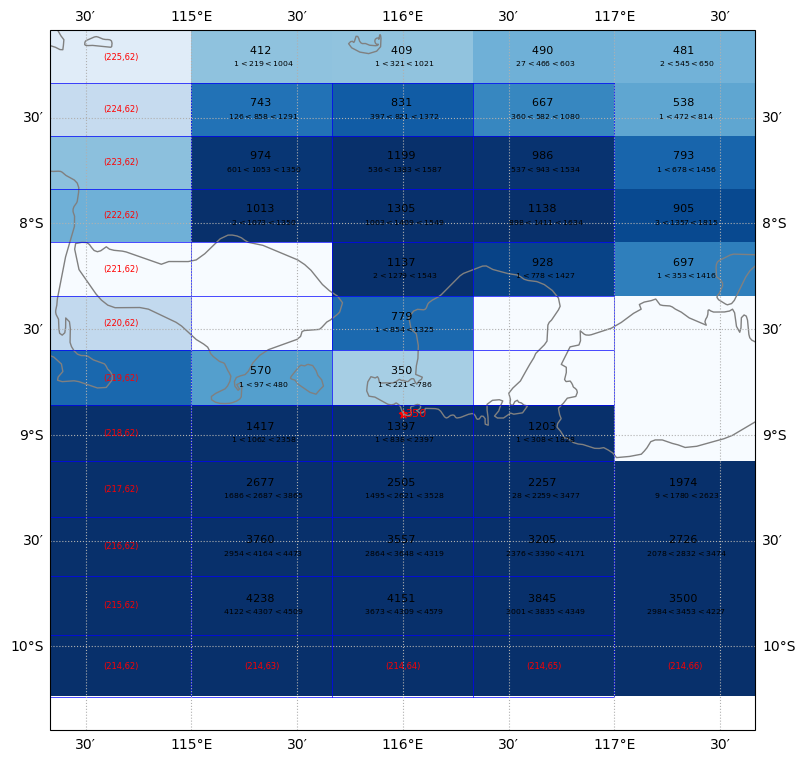

In [41]:
i = np.array([64,],np.int32)
j = np.array([219,],np.int32)
z = np.array([350,],float)
n = np.shape(j)[0]
print(n)
for n in range(n) :
    dss[depth_var_new][j[n],i[n]] = z[n]
    
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

        
iEdit = np.concatenate((iEdit,i))
jEdit = np.concatenate((jEdit,j))
zEdit = np.concatenate((zEdit,z))

### Bab El-Mandeb

{'lat': 13.73, 'lon': 42.5, 'depth': 137.0, 'width': 32.0}


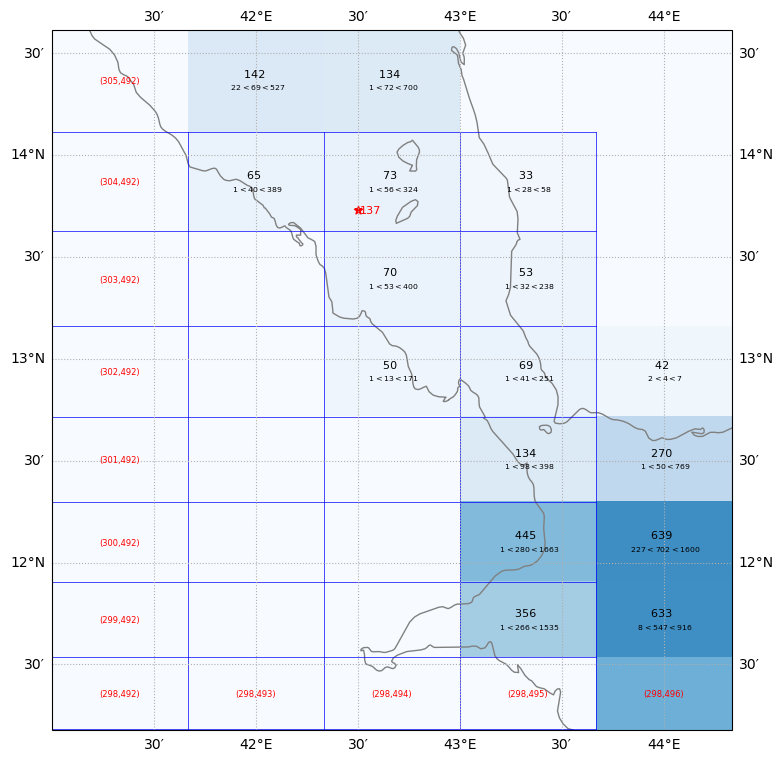

In [42]:
place = 'Bab El-Mandeb'
print(soc_table[place])
lon_beg = 41.5
lon_end = 44.5
lat_beg = 11.5
lat_end = 14.75
zmax = 1000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

### St of Hormuz

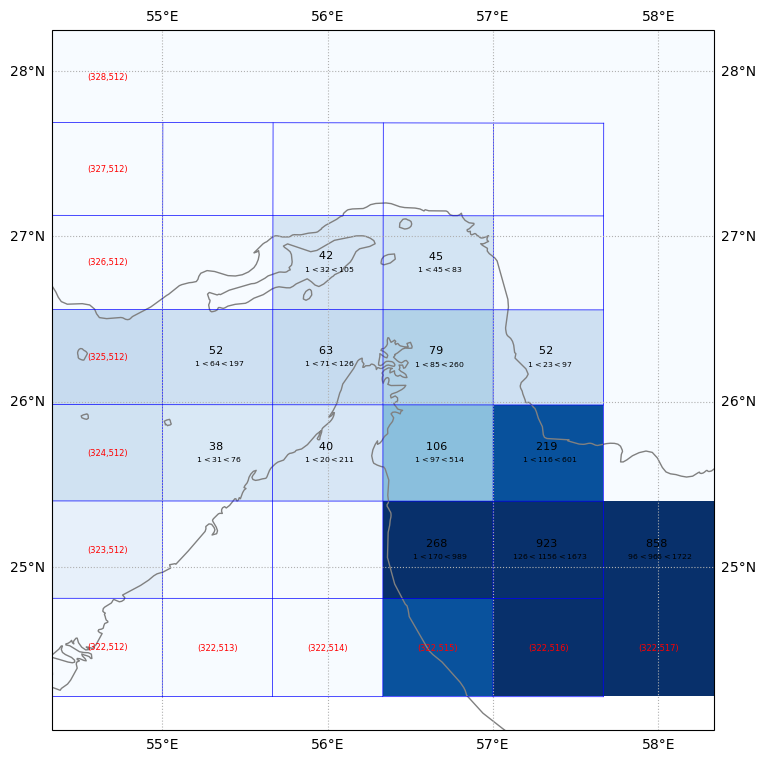

In [43]:
lon_beg = 54.5
lon_end = 59
lat_beg = 24.5
lat_end = 28.5
zmax = 250.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

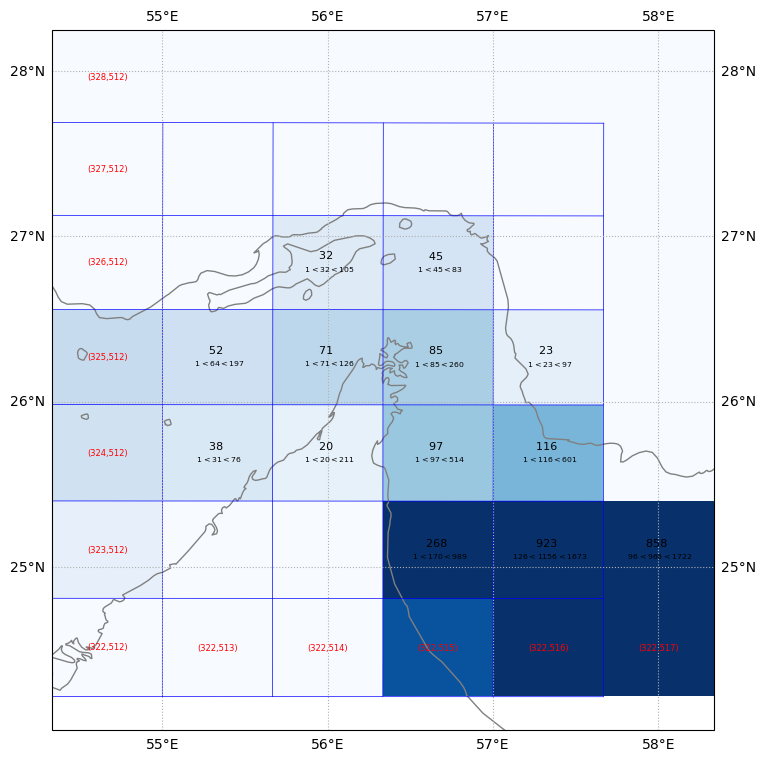

In [44]:
for i in range(514,517):
    for j in range(324,327):
        if dss['mask'][j,i] != 0 :
            z = dss['D_median'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))        

        
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax)

### Samoa Passage

{'lat': -8.66, 'lon': -169.0, 'depth': 4800.0, 'width': 200.0}


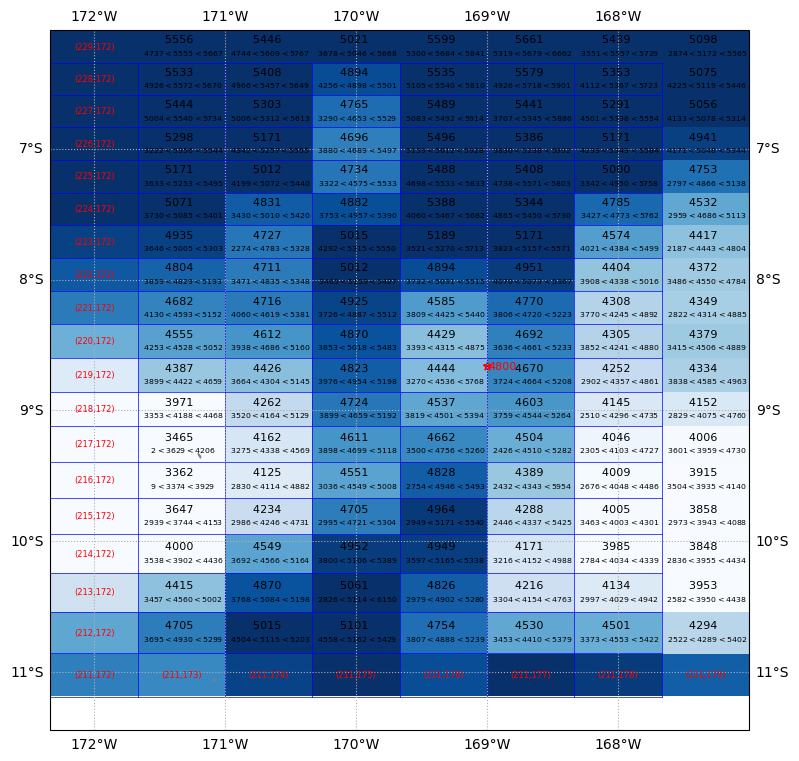

In [45]:
place = 'Samoa Passage'
print(soc_table[place])
lon_beg = -172
lon_end = -167
lat_beg = -11
lat_end = -6
zmax = 5000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,
                zmin=4000,zmax=zmax,place=soc_table[place])

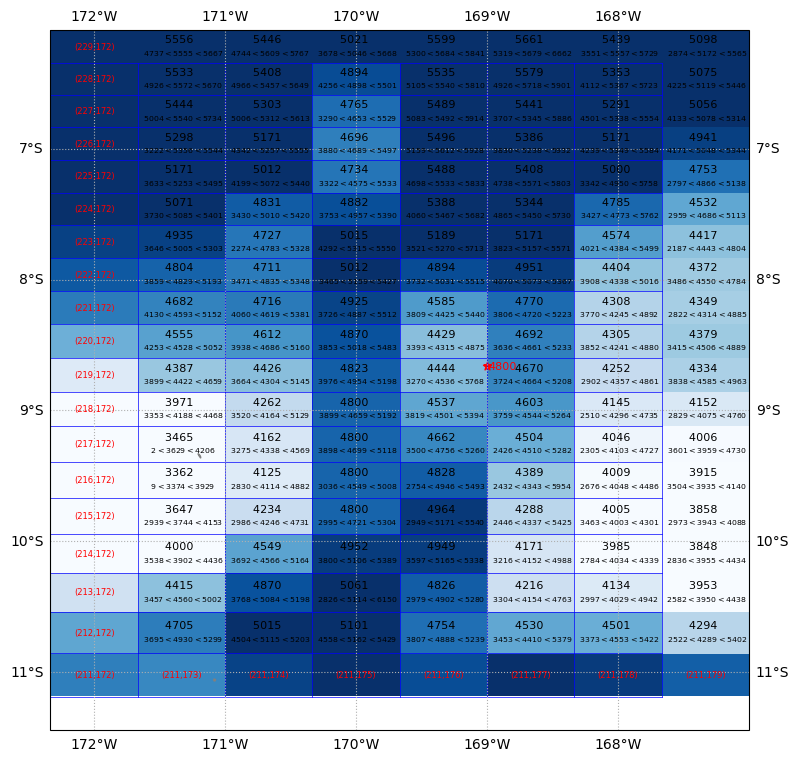

In [46]:
# Use SOC table sill depth
i=175
for j in range(215,219):
    if dss['mask'][j,i] != 0 :
        z = 4800
        dss[depth_var_new][j,i] = z

        iEdit = np.concatenate((iEdit,(i,)))
        jEdit = np.concatenate((jEdit,(j,)))
        zEdit = np.concatenate((zEdit,(z,)))        

        
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,
                zmin=4000,zmax=zmax,place=soc_table[place])

### Bering St.

{'lat': 64.25, 'lon': -171.6, 'depth': 50.0, 'width': 85.0}


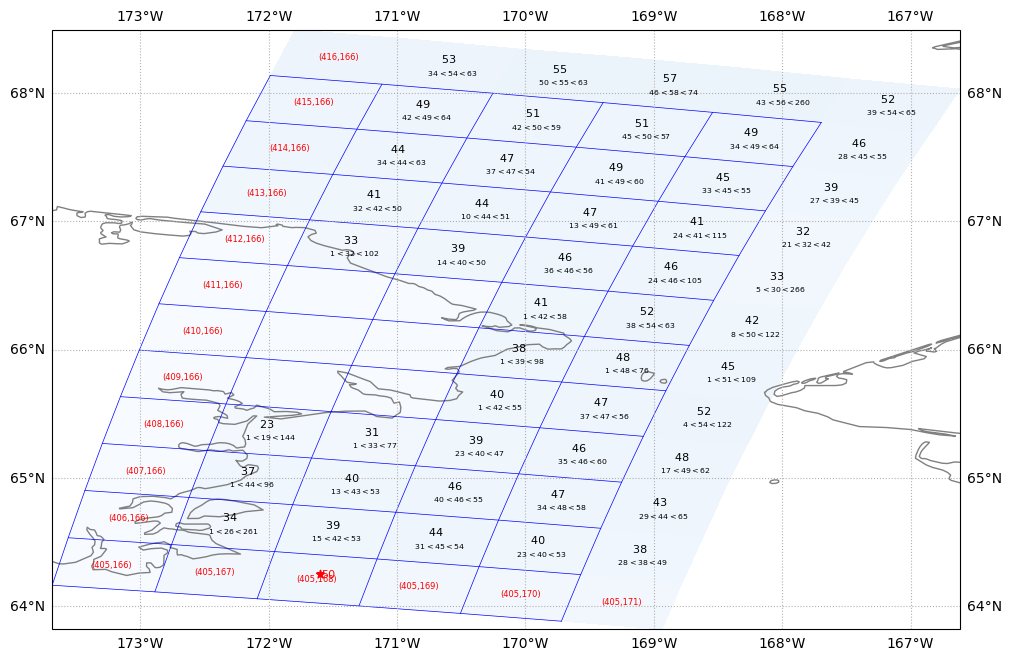

In [47]:
place = 'Bering St.'
print(soc_table[place])
lon_beg = -173
lon_end = -166
lat_beg = 64.5
lat_end = 68
zmax = 1000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

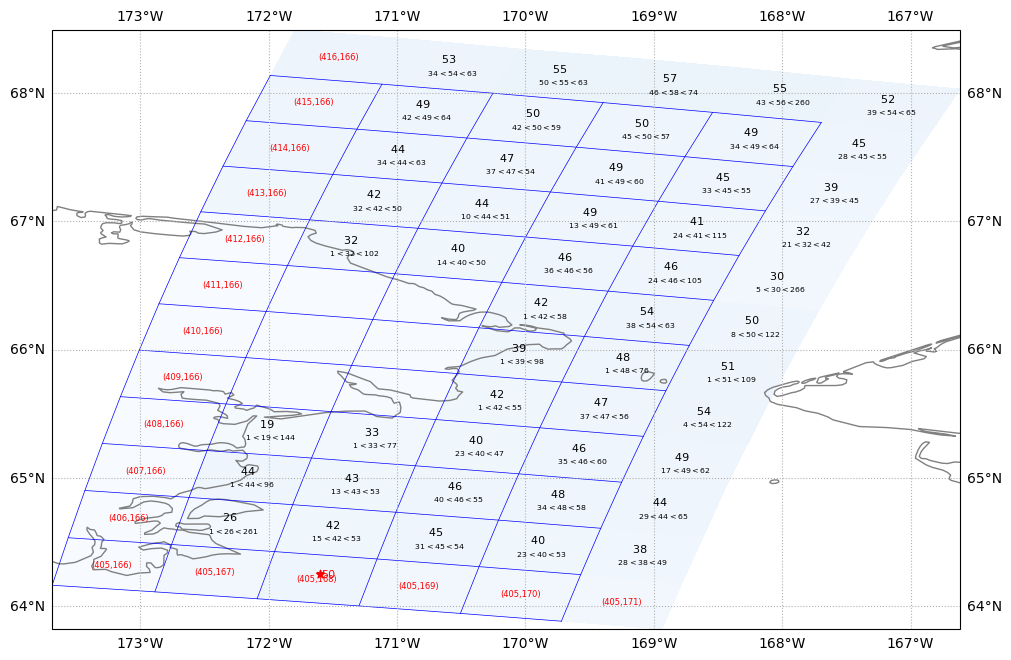

In [48]:
# use the cell median around the sill
for i in range(167,172):
    for j in range(405,416):
        if dss['mask'][j,i] != 0 :
            z = dss['D_median'][j,i]
            dss[depth_var_new][j,i] = z

            iEdit = np.concatenate((iEdit,(i,)))
            jEdit = np.concatenate((jEdit,(j,)))
            zEdit = np.concatenate((zEdit,(z,)))        

        
ax=inspect_topo(dss,depth_var_new,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])


## Set up output file

## Create output dataset

In [49]:
nlong = np.int32(np.shape(dss[depth_var_new])[0])
nlatg = np.int32(np.shape(dss[depth_var_new])[1])
print(nlong,nlatg)

nEdits = np.shape(zEdit)
ds_edits = xr.Dataset(
 {'iEdit': (['nEdits'], iEdit.astype('int32'), {'long_name' : "i-index of edited depth"}),
  'jEdit': (['nEdits'], jEdit.astype('int32'), {'long_name' : "j-index of edited depth"}),
  'zEdit': (['nEdits'], zEdit, {'long_name' : "New value of depth", 'units' : 'meters'}),
 }
  )
ds_edits.attrs['title'] = 'Topography Edits'
ds_edits.attrs['original grid'] = file_in

ds_edits

480 540


<xarray.Dataset> Size: 6kB
Dimensions:  (nEdits: 367)
Dimensions without coordinates: nEdits
Data variables:
    iEdit    (nEdits) int32 1kB 78 78 78 78 78 78 78 ... 171 171 171 171 171 171
    jEdit    (nEdits) int32 1kB 260 261 262 263 264 265 ... 411 412 413 414 415
    zEdit    (nEdits) float64 3kB 900.0 900.0 400.0 500.0 ... 31.82 38.52 44.98
Attributes:
    title:          Topography Edits
    original grid:  topo.sub150.tx2_3v3.SRTM15_V2.4.edit1.SmL1.0_C1.0.nc

In [50]:
ds_out = xr.merge([dss, ds_edits])
ds_out

<xarray.Dataset> Size: 21MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541, nEdits: 367)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Dimensions without coordinates: nEdits
Data variables: (12/19)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
    D_edit2     (lath, lonh) float32 1MB ...
    iEdit       (nEdits) int32 1kB 78 78 78 78 78 78 ... 171 171 171 171 171 171
    jEdit       (nEdits) int32 1kB 260 261 262 263 264 ... 411 412 413 414 415
    zEdit       (nEdits) float64 3kB 900.0 900.0 400.0 ... 31.82 38.52 44.98
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260226
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/27/2026

In [51]:
ds_out.attrs['Manual edits updated on:'] =  datetime.now().isoformat()
ds_out.attrs['By:'] = 'Frank Bryan (bryan@ucar.edu)'
ds_out.attrs['url'] = 'https://github.com/NCAR/tx2_3/topography/'

In [52]:
print(path_out+file_out)

./topo.sub150.tx2_3v3.SRTM15_V2.4.edit2.SmL1.0_C1.0.nc


In [53]:
ds_out.to_netcdf(path_out+file_out)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(
